In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

## Data Loading and Filtering

In [4]:
videos_df = pd.read_csv('raw_data/videos_info.csv')
videos_df.head(2)

/tmp/ipykernel_1892/1622787395.py:1: DtypeWarning: Columns (5,8,9,12,13,16,17,18,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  videos_df = pd.read_csv('raw_data/videos_info.csv')


,video_id,title,description,channel_id,published_at,category_id,tags,view_count,like_count,comment_count,...,scheduled_end_time,concurrent_viewers,active_live_chat_id,recording_date,topicCategories,processing_status,parts_total,parts_processed,time_left_ms,processing_failure_reason
0,BaB4LEZFipU,Les réalités scientifiques sur les vapoteuses,Alors que l’interdiction de la puff a été voté...,UCp2kK3DyhpgFOdILF3BBC9A,2023-12-16T17:00:13Z,25,"[""l'express"", ""l'express vidéo"", 'express vidé...",585.0,13,1,...,NaN,0.0,NaN,NaN,"['https://en.wikipedia.org/wiki/Health', 'http...",NaN,0.0,0.0,0.0,NaN
1,7FrvJpYMYjI,Alerte aux nouvelles drogues : moins chères et...,Censée décupler les sensations de plaisir et d...,UCwN9rWRNCARylvpRAvbbjxg,2023-12-19T18:12:33Z,1,"['arte reportage', 'arte', 'documentaire 2022'...",349857.0,2397,589,...,NaN,0.0,NaN,NaN,['https://en.wikipedia.org/wiki/Society'],NaN,0.0,0.0,0.0,NaN


In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
nltk.download('punkt')

# On enlève les vidéos en double
video_df = videos_df.drop_duplicates(subset=['video_id'])
#on reformate la date
video_df['published_at'] = video_df['published_at'].str.slice(0, 10)

start_date = '2018-01-01'
end_date = '2023-12-31'
video_df = video_df[(video_df['published_at'] >= start_date) & (video_df['published_at'] <= end_date)]

#On set up les stopwords
stopwords_english = set(stopwords.words('english'))
stopwords_french = set(stopwords.words('french'))
custom_stopwords= set(["Acer","acer","ACER"])
final_stopwords = stopwords_english.union(stopwords_french,custom_stopwords)

# keywords = [
#     # "cigarette électronique", "nicotine", "saveur", "mod", "résistance", "vapoter",
#     # "jus", "réservoir", "batterie", "liquide", "cartouche", "atomiseur", "ecig", "e-liquide",
#     # "kit de démarrage", "juul", "smok", "geekvape", "voopoo", "aspire", "eleaf", "innokin",
#     # "vuse", "vaporesso", "freemax", "joyetech", "vape", "e-cigarette", "flavor", "coil",
#     # "vaping", "vaper", "juice", "tank", "battery", "liquid", "pod", "pen", "cloud", "atomizer",
#     # "ejuice", "eliquid", "starter kit", "flavor chaser", "nic salt", "freebase nicotine","elfbar","elf bar",
#     # "Ignite","Uwell","Caliburn","Argus","DOTMOD","GEEK VAPE","Innokin","Joyetech","Justfog",
    
#     #Adding some variations
#     "cigarette", "cigarette électronique", "nicotine", "saveur", "mod", "résistance", "vapoter", "jus",
#     "réservoir", "batterie", "liquide", "cartouche", "atomiseur", "ecig", "e-liquide", 
#     "kit de démarrage", "juul", "smok", "geekvape", "voopoo", "aspire", "eleaf", "innokin", 
#     "vuse", "vaporesso", "freemax", "joyetech", "vape", "e-cigarette", "flavor", "coil", "vaping", 
#     "vaper", "juice", "tank", "battery", "liquid", "pod", "pen", "cloud", "atomizer", "ejuice",
#     "eliquid", "starter kit", "flavor chaser", "nic salt", "freebase nicotine", "elfbar", 
#     "elf bar", "Ignite", "Uwell", "Caliburn", "Argus", "DOTMOD", "GEEK VAPE", "Innokin",
#     "Joyetech", "Justfog", "taux de nicotine", "tabac chauffé", "glycerine", "glycerol",
#     "drip-tip", "mesh", "dl", "mtl", "dry-hit", "throat hit", "vaporisateur", "puff", "cloud chaser", 
#     "flacon", "fil résistif", "mod box", "mod mécanique", "rta", "rda", "rdta", "e-cig", "vape pen",
#     "vape mod", "dripper", "clearomiseur", "sub-ohm", "microcoil", "cotonnage", "vapeur",
#     "e-vape", "power vaping", "nasty", "oxva", "vape","xim pro"]


keywords = [
    "cigarette", "cigarettes", "cigarette électronique", "cigarettes électroniques", 
    "nicotine", "nicotines", "saveur", "saveurs", "mod", "mods", "résistance", "résistances", 
    "vapoter", "vapote", "vapotes", "vapoteur", "vapoteurs", "vapoteuse", "vapoteuses", "jus", 
    "réservoir", "réservoirs", "batterie", "batteries", "liquide", "liquides", "cartouche", 
    "cartouches", "atomiseur", "atomiseurs", "ecig", "ecigs", "e-liquide", "e-liquides", 
    "kit de démarrage", "kits de démarrage", "juul", "juuls", "smok", "geekvape", "voopoo", 
    "aspire", "eleaf", "innokin", "vuse", "vaporesso", "freemax", "joyetech", "vape", "vapes", 
    "e-cigarette", "e-cigarettes", "flavor", "flavors", "coil", "coils", "vaping", "vaper", 
    "vapers", "vapeur", "vapeurs", "vapeuse", "vapeuses", "juice", "juices", "tank", "tanks", 
    "battery", "batteries", "liquid", "liquids", "pod", "pods", "pen", "pens", "cloud", "clouds", 
    "atomizer", "atomizers", "ejuice", "ejuices", "eliquid", "eliquids", "starter kit", "starter kits", 
    "flavor chaser", "flavor chasers", "nic salt", "nic salts", "freebase nicotine", 
    "freebase nicotines", "elfbar", "elfbars", "elf bar", "elf bars", "Ignite", "Ignites", "Uwell", 
    "Uwells", "Caliburn", "Caliburns", "Argus", "Arguses", "DOTMOD", "DOTMODs", "GEEK VAPE", 
    "GEEK VAPEs", "Innokin", "Innokins", "Joyetech", "Joyetechs", "Justfog", "Justfogs", 
    "taux de nicotine", "taux de nicotines", "tabac chauffé", "tabacs chauffés", "glycerine", 
    "glycerines", "glycerol", "glycerols", "drip-tip", "drip-tips", "mesh", "meshes", "dl", "mtl", 
    "dry-hit", "dry-hits", "throat hit", "throat hits", "vaporisateur", "vaporisateurs", "puff", 
    "puffs", "cloud chaser", "cloud chasers", "flacon", "flacons", "fil résistif", "fils résistifs", 
    "mod box", "mod boxes", "mod mécanique", "mods mécaniques", "rta", "rtas", "rda", "rdas", 
    "rdta", "rdtas", "e-cig", "e-cigs", "vape pen", "vape pens", "vape mod", "vape mods", "dripper", 
    "drippers", "clearomiseur", "clearomiseurs", "sub-ohm", "sub-ohms", "microcoil", "microcoils", 
    "cotonnage", "cotonnages", "vapeur", "vapeurs", "e-vape", "e-vapes", "power vaping", "nasty", 
    "oxva", "oxvas",  "xim pro", "xim pros"
]

keywords = [word for word in keywords if word not in final_stopwords]

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smartdata_ig/c.ferreira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/smartdata_ig/c.ferreira/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_1892/3921581388.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_df['published_at'] = video_df['published_at'].str.slice(0, 10)


In [7]:
# Two options: 
# Option 1. Filtering by substring: This means if we include "cig" in the set of keywords, titles with words like "e-cig" or "cigarettes" will be matched.
# Option 2. Filtering by exact word: In this case, only titles containing the exact word "cig" will be matched, regardless of case. This requires creating sets with plurals, for example, "cigarette" and "cigarettes".

# Option 1
# Count videos that contain at least one keyword in the title
videos_with_keyword = video_df[video_df['title'].str.contains('|'.join(keywords), case=False, na=False)]

# # Option 2
# # Create a regular expression pattern for exact words
# pattern = r'\b(?:' + '|'.join(re.escape(keyword) for keyword in keywords) + r')\b'
# # Filter videos based on regular expression pattern
# videos_with_keyword = video_df[video_df['title'].str.contains(pattern, case=False, na=False)]

##Finally
# Custom list of words to exclude
exclude_words = [
  "podcast", "music", "time", "lyric", "Andaman", "Nicobar", "island", "Alan Walker", 
  "Music Video", "type beat", "Lucid Dream", "Juice WRLD", "WRLD", "rugby", "Mobile Legend",
  "drink", "asmr", "ft", "feat", "Weed", "Food", "vlog", "cbd", "acer", "Joe Rogan", "alan walker", 
    "music", "street food", "recette", "Official music", "day","big","king", "walker", "easy", "lyric"
]

# Create a regex pattern for the words to exclude
exclude_pattern = r'\b(?:' + '|'.join(re.escape(word) for word in exclude_words) + r')\b'

# Filter out videos with titles containing any of the exclude words
videos_with_keyword = videos_with_keyword[~videos_with_keyword['title'].str.contains(exclude_pattern, case=False, na=False)]

print("Total number of videos:", len(video_df))
print("Number of videos with at least one keyword in the title:", len(videos_with_keyword))

Total number of videos: 70387
Number of videos with at least one keyword in the title: 37954


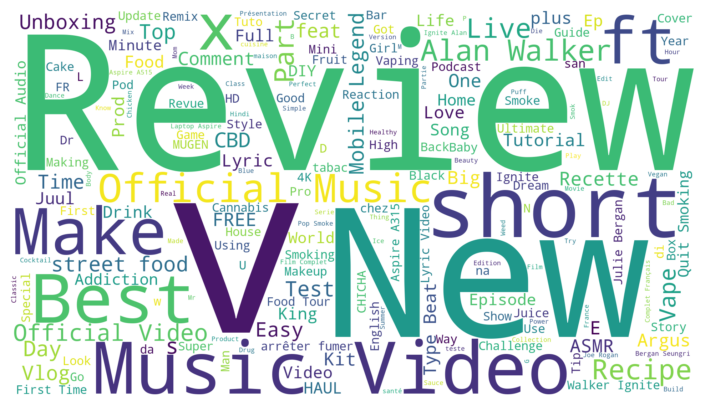

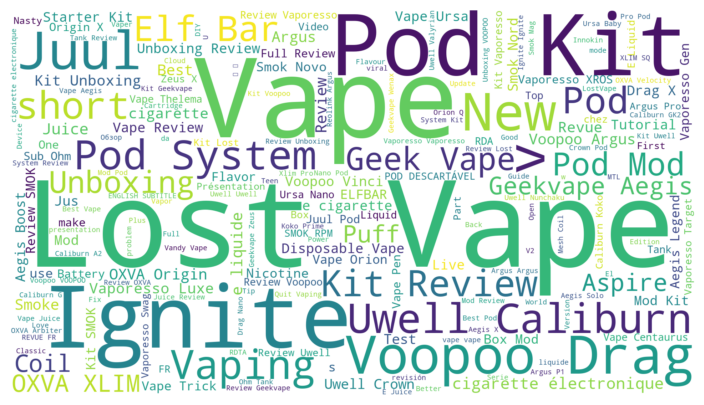

In [8]:
# Filtrando videos que possuem as palavras chaves
videos_with_keywords = video_df[video_df['title'].str.contains('|'.join(keywords), case=False, na=False)]
# Filtrando videos que não possuem as palavras chaves
videos_without_keywords = video_df[~video_df['title'].str.contains('|'.join(keywords), case=False, na=False)]

# Filtrando videos que possuem as palavras excluídas
videos_with_excluded_words = videos_with_keywords[videos_with_keywords['title'].str.contains('|'.join(exclude_words), case=False, na=False)]

# DF Contendo os títulos filtrados
filtered_videos = videos_with_keywords[~videos_with_keywords['title'].str.contains('|'.join(exclude_words), case=False, na=False)]
filtered_titles = filtered_videos['title']
# DF Contendo os títulos excluídos
excluded_titles = pd.concat([videos_without_keywords, videos_with_excluded_words], axis=0)['title']

# Limpando os títulos removendo as stopwords
def clean_titles(titles):
    return titles.apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in final_stopwords]))

cleaned_excluded_titles = clean_titles(excluded_titles)
cleaned_filtered_titles = clean_titles(filtered_titles)

# Plotando as nuvens de palavras
def plot_word_cloud(titles, file_name):
    wordcloud = WordCloud(width=1920, height=1080, background_color='white').generate(' '.join(titles))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.savefig(file_name, bbox_inches='tight')
    plt.show()

plot_word_cloud(cleaned_excluded_titles, 'figs/cleaned_excluded_titles.png')
plot_word_cloud(cleaned_filtered_titles, 'figs/cleaned_filtered_titles.png')

In [10]:
filtered_videos.to_csv('cleaned_data/filtered_videos_with_keywords_substring.csv', index=False)
filtered_videos.head()

,video_id,title,description,channel_id,published_at,category_id,tags,view_count,like_count,comment_count,...,scheduled_end_time,concurrent_viewers,active_live_chat_id,recording_date,topicCategories,processing_status,parts_total,parts_processed,time_left_ms,processing_failure_reason
0,BaB4LEZFipU,Les réalités scientifiques sur les vapoteuses,Alors que l’interdiction de la puff a été voté...,UCp2kK3DyhpgFOdILF3BBC9A,2023-12-16,25,"[""l'express"", ""l'express vidéo"", 'express vidé...",585.0,13,1,...,NaN,0.0,NaN,NaN,"['https://en.wikipedia.org/wiki/Health', 'http...",NaN,0.0,0.0,0.0,NaN
3,9UAKK7SPklc,"C'est quoi le problème, avec les puffs ?",L'Assemblée nationale vient de voter leur inte...,UCYpRDnhk5H8h16jpS84uqsA,2023-12-06,25,"['le monde', 'lemonde', 'actualité', 'news', '...",51322.0,987,33,...,NaN,0.0,NaN,NaN,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,0.0,0.0,0.0,NaN
6,e-04gbV00J4,DaVap Vaporisateur Mécanique Français - Derniè...,"Hello, une dernière vue sur le prototype avant...",UC2ynzxFg1aAstuLxf6l1orw,2023-12-12,22,[],212.0,21,7,...,NaN,0.0,NaN,NaN,"['https://en.wikipedia.org/wiki/Hobby', 'https...",NaN,0.0,0.0,0.0,NaN
10,-Gwdc5EHk6U,Raga AIO par Aspire - La revue old school,Qui a dit qu’il n’y en avait que pour les débu...,UCOds3c32BT1Y0laKyq_KOpA,2023-12-04,27,"['vape', 'cigarette électronique', 'ecig', 'pu...",1256.0,31,4,...,NaN,0.0,NaN,NaN,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,0.0,0.0,0.0,NaN
19,b53Iz5_NLC0,Varroabehandlung | Effektiv & Erfolgreich | Bi...,Hallihallo aus Köln!\n\nHeute geht es um unser...,UC5hkuMRRCJhj-n16PpEt9aw,2023-12-14,22,"['bienendom', 'Bienen', 'Imkerei', 'Bienenköni...",16898.0,593,139,...,NaN,0.0,NaN,NaN,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,0.0,0.0,0.0,NaN


## Comments Language Detection

In [11]:
import pandas as pd
import pickle
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from tqdm.autonotebook import tqdm

# Function to save the current state of the language detection dictionary incrementally
def save_state(language_dict, filename="dict_language_detected.pkl"):
    with open(filename, "wb") as f:
        pickle.dump(language_dict, f)

# Function to load the saved state
def load_state(filename='dict_language_detected.pkl'):
    try:
        with open(filename, "rb") as f:
            return pickle.load(f)
    except FileNotFoundError:
        print(f"File {filename} not found.")
        return {}
    except pickle.UnpicklingError:
        print(f"Error unpickling file {filename}.")
        return {}
    except Exception as e:
        print(f"An error occurred: {e}")
        return {}

# Load the model and tokenizer for language detection
model_ckpt = "papluca/xlm-roberta-base-language-detection"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt).to(device)

# Load previous state if exists
dict_comment_language = load_state()

# We will only filter comments belonging to the pre-selected videos and within the target range date
df_comments = pd.read_csv("raw_data/comments_info_corrected.csv", on_bad_lines='warn', encoding='utf-8', sep=',', lineterminator='\n')
videos_with_keyword = pd.read_csv('cleaned_data/filtered_videos_with_keywords_substring.csv')
df_comments['comment'] = df_comments['comment'].astype(str)
df_comments['published_at'] = pd.to_datetime(df_comments['published_at'])
start_date = '2018-01-01'
end_date = '2023-12-31'
df_comments = df_comments[(df_comments['published_at'] >= start_date) & (df_comments['published_at'] <= end_date)]
df_comments = df_comments[df_comments['video_id'].isin(videos_with_keyword['video_id'])]
dict_comments_to_detect_language = dict(zip(df_comments["comment_id"].astype(str), df_comments["comment"]))
del videos_with_keyword

# Ensure dict_comment_language keys are strings
dict_comment_language = {str(k): v for k, v in dict_comment_language.items()}

# Identify unprocessed comment IDs
unprocessed_comment_ids = [comment_id for comment_id in dict_comments_to_detect_language if comment_id not in dict_comment_language]

# Print debug information
print(f"Total comments to process: {len(dict_comments_to_detect_language)}")
print(f"Total processed comments: {len(dict_comment_language)}")
print(f"Total unprocessed comments: {len(unprocessed_comment_ids)}")

# Function to process comments and update the language dictionary
def process_comments(comment_ids, comments, dict_comment_language, save_interval=20000, batch_size=256):
    save_count = 0
    unprocessed_items = [(id, comment) for id, comment in zip(comment_ids, comments) if id in unprocessed_comment_ids]

    if not unprocessed_items:
        print("No unprocessed comments found.")
        return

    for i in tqdm(range(0, len(unprocessed_items), batch_size), desc="Processing Comments"):
        batch_items = unprocessed_items[i:i + batch_size]
        batch_ids, batch_comments = zip(*batch_items)  # Unpack IDs and comments

        # Batch tokenization
        inputs = tokenizer(list(batch_comments), padding=True, truncation=True, max_length=512, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}  # Move to device

        # Model inference
        with torch.no_grad():
            logits = model(**inputs).logits

        # Softmax to get probabilities
        preds = torch.softmax(logits, dim=-1)
        max_idxs = preds.argmax(dim=1).tolist()

        # Assign detected language to each comment in the batch
        for comment_id, max_idx in zip(batch_ids, max_idxs):
            language = model.config.id2label[max_idx]
            dict_comment_language[comment_id] = language
            save_count += 1

            # Save the current state every save_interval comments
            if save_count >= save_interval:
                save_state(dict_comment_language)
                save_count = 0

        # Clear CUDA cache
        del inputs, logits, preds
        torch.cuda.empty_cache()

    # Save any remaining comments after the loop
    save_state(dict_comment_language)

# Let's make it in batches
comments = [dict_comments_to_detect_language[id] for id in unprocessed_comment_ids]

# Process comments
process_comments(unprocessed_comment_ids, comments, dict_comment_language)

# Save any remaining unprocessed IDs for further analysis
remaining_unprocessed_ids = [k for k in unprocessed_comment_ids if k not in dict_comment_language]
with open("remaining_unprocessed_ids.txt", "w") as f:
    for comment_id in remaining_unprocessed_ids:
        f.write(f"{comment_id}\n")

# Map languages to comments and update DataFrame
df_comments['comment_id'] = df_comments['comment_id'].astype(str)
df_comments['language'] = df_comments['comment_id'].map(dict_comment_language)
print("Total of comments without language", df_comments['language'].isna().sum())
df_comments.to_csv("cleaned_data/comments_info_language_roBERTa_substring.csv", index=False)

Total comments to process: 5439982
Total processed comments: 9034127
Total unprocessed comments: 0
No unprocessed comments found.
Total of comments without language 0


**Language Tool: Second language check**

In [12]:
!pip install langdetect

In [ ]:
# RoBERTa didn't perform very well on noisy comments. For example: Kkkk Okkk. Merciiiii!
# It's worth adding a second attempt. If it doesn't pass any of them, it won't be useful for our model either
# because the noise level is really very high! This is common in social networks!!!
# Therefore, I made a second pass for those that were not considered as FR (French) by LangDetect.
# With this, we assume that if the comment is considered FR by at least one of the APIs, it is included in the analysis.
from langdetect import detect
import pandas as pd 
from tqdm.autonotebook import tqdm


def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unidentified'  # Retorna isso se não conseguir detectar 

df_comments = pd.read_csv("cleaned_data/comments_info_language_roBERTa_substring.csv", on_bad_lines='skip', encoding='utf-8', sep=',', lineterminator='\n')
df_comments['published_at'] = pd.to_datetime(df_comments['published_at'])
df_comments = df_comments.dropna(subset=['published_at'])
tqdm.pandas(desc="Detecting languages")
df_comments.loc[df_comments['language'] != 'fr', 'language_langdetect'] = df_comments[df_comments['language'] != 'fr']['comment'].progress_apply(detect_language)
df_comments.to_csv("cleaned_data/final_commments_all_language_vape.csv", index=False)
df_comments_fr = df_comments[(df_comments['language'] =='fr') | (df_comments['language_langdetect'] =='fr')]
print("Total of comments belonging to filtered videos and in french", len(df_comments_fr))
df_comments_fr.to_csv("cleaned_data/final_commments_fr_vape_substring.csv", index=False)

In [4]:
df_comments = pd.read_csv("cleaned_data/comments_info_language_roBERTa_substring.csv", on_bad_lines='skip', encoding='utf-8', sep=',', lineterminator='\n')
df_comments[(df_comments['language'] =='fr')]

,video_id,comment_id,author,author_profile_image_url,author_channel_url,author_channel_id,comment,published_at,updated_at,like_count,viewer_rating,can_rate,is_reply,parent_id,channel_id,language
0,BaB4LEZFipU,UgxPR0_IDmNKSqtoqEF4AaABAg,@bouhschnou,https://yt3.ggpht.com/ytc/AIdro_nmrgOj8FjLrysO...,http://www.youtube.com/@bouhschnou,UCNDd8CfcrNHQvpxOHmgoJtw,@14:50 en faisant soi-même son mélange (nicoti...,2023-12-27 14:22:12+00:00,2023-12-27T14:22:12Z,0.0,none,True,False,NaN,UCp2kK3DyhpgFOdILF3BBC9A,fr
1,9UAKK7SPklc,Ugy2HM-9ljEgGGK-uGF4AaABAg,@maverickmike4459,https://yt3.ggpht.com/ytc/AIdro_lK6O2W2e3JHV4f...,http://www.youtube.com/@maverickmike4459,UC3XgmZT7yZoO2z3j34h0ZKQ,lol on parle d écologie sur une clope mais ...,2023-12-15 05:47:52+00:00,2023-12-15T05:47:52Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr
2,9UAKK7SPklc,UgwhQUcSfwqFrk1Yx1N4AaABAg,@orevwar5452,https://yt3.ggpht.com/xuXb8yKJ1sOkZjnlYppfl8-N...,http://www.youtube.com/@orevwar5452,UCXASwJZkETZYFWKl2tYulKg,Ça fait depuis 10ans que ça existent..,2023-12-13 21:02:34+00:00,2023-12-13T21:02:34Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr
3,9UAKK7SPklc,Ugy-rE7KrWwj9OIoGkp4AaABAg,@aspirateur2000,https://yt3.ggpht.com/DWhiaCOTbJxmLUDLAVQbu3B8...,http://www.youtube.com/@aspirateur2000,UCcvjVnHe3e1bKZWLlI1MfmQ,Reste juste la question principale qui est: es...,2023-12-12 22:10:15+00:00,2023-12-12T22:11:03Z,2.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr
4,9UAKK7SPklc,UgxqZXypSN0IUQbWold4AaABAg,@alansair4421,https://yt3.ggpht.com/ytc/AIdro_kYk_I7qsC63KqW...,http://www.youtube.com/@alansair4421,UCvNNvEzqGaGdSKT2IMAycPA,Problème de son,2023-12-11 22:19:41+00:00,2023-12-11T22:19:41Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439159,JFlQxtGYcKs,UgyZE3bx9TrOaAlqED54AaABAg.8avnYRwueTN8avuAYGdqhO,@dr4gix.,https://yt3.ggpht.com/3Zy1JT-SyznuCrYrzxp6Ez6F...,http://www.youtube.com/@dr4gix.,UCUkjKj9tFnnpghOkbJ4lMLA,Toujours dessus ^^,2018-01-02 19:45:46+00:00,2018-01-02T19:45:46Z,0.0,none,True,True,UgyZE3bx9TrOaAlqED54AaABAg,UCUkjKj9tFnnpghOkbJ4lMLA,fr
5439160,JFlQxtGYcKs,UgyfFTIOIR24-epE4Q94AaABAg,@soulah8565,https://yt3.ggpht.com/ytc/AIdro_lcF_sEa8xOzuy7...,http://www.youtube.com/@soulah8565,UCjhELIch7SNLrtM5cKX1KYQ,GG tu gères <3 continue comme sa,2018-01-02 09:17:10+00:00,2018-01-02T09:17:10Z,1.0,none,True,False,NaN,UCUkjKj9tFnnpghOkbJ4lMLA,fr
5439161,JFlQxtGYcKs,UgyfFTIOIR24-epE4Q94AaABAg.8aumETpAWbx8aumMVFGWA2,@dr4gix.,https://yt3.ggpht.com/3Zy1JT-SyznuCrYrzxp6Ez6F...,http://www.youtube.com/@dr4gix.,UCUkjKj9tFnnpghOkbJ4lMLA,Sou Lah Merci beaucoup :),2018-01-02 09:18:15+00:00,2018-01-02T09:18:15Z,0.0,none,True,True,UgyfFTIOIR24-epE4Q94AaABAg,UCUkjKj9tFnnpghOkbJ4lMLA,fr
5439162,JFlQxtGYcKs,UgyfFTIOIR24-epE4Q94AaABAg.8aumETpAWbx8aumTRYnwiy,@soulah8565,https://yt3.ggpht.com/ytc/AIdro_lcF_sEa8xOzuy7...,http://www.youtube.com/@soulah8565,UCjhELIch7SNLrtM5cKX1KYQ,a oui et j'ai oublier de le dire Sou Lah enfai...,2018-01-02 09:19:12+00:00,2018-01-02T09:19:12Z,0.0,none,True,True,UgyfFTIOIR24-epE4Q94AaABAg,UCUkjKj9tFnnpghOkbJ4lMLA,fr


In [ ]:
# Calculate the required statistics
num_unique_channels = filtered_videos['channel_id'].nunique()
num_unique_videos = filtered_videos['video_id'].nunique()
num_comments = df_comments_fr.shape[0]
num_unique_users = df_comments_fr['author_channel_id'].nunique()

num_unique_channels, num_unique_videos, num_comments, num_unique_users

## Comments Sampling To Label

In [2]:
import pandas as pd

# Load data from CSV files
df_videos = pd.read_csv("cleaned_data/filtered_videos_with_keywords.csv")
df_comments = pd.read_csv("cleaned_data/final_commments_fr_vape.csv")

/tmp/ipykernel_95/4007879568.py:5: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_comments = pd.read_csv("cleaned_data/final_commments_fr_vape.csv")


In [23]:
# Define the number of comments to be sampled
N_COMMENTS=0 # 30
N_COMMENTS_FROM_KEYWORD=5 #15

# List of keywords to filter comments, translated to French
keywords = ['adolescent', 'eau dans les poumons', 'agent cancérigène', 'aide', 'alerte', 'piège', 
            'arôme', 'avc', 'conséquences', 'consommation', 'discuter', 'petit enfant', 
            'enfant', 'enfants', 'cancer', 'dépendance', 'branché', 
            'débridé', 'malade', 'maladie', 'maladies', 'œdème pulmonaire', 
            'embolie pulmonaire', 'épidémie', 'école', 'evali', 'essoufflement',
            'fait mal', 'fièvre', 'feu', 'fumeurs', 'hôpitaux', 'hôpital', 'infantile',
            'crise cardiaque', 'inflammation', 'hospitalisé', 'hospitalisation', 'hospitalisations', 'intubée', 
            'intubé', 'intubation', 'jeune', 'jeunes', 'arrêter de fumer', 'j\'ai arrêté', 
            'lésionné', 'lésion', 'libre', 'mal', 'effets nocifs', 'tuer', 'mourir', 'mort',
            'plus jamais', 'je n\'ai plus jamais fumé', 'ne fumez pas', 'pas sain', 'arrêter de fumer', 
            'arrête de fumer', 'arrêtez de fumer', 'perforation pulmonaire', 'danger', 'dangereux', 'gorge',
            'saleté', 'interdire', 'interdiction', 'pulmonaire', 'poumon', 'colère', 'reportage', 'reporter', 'risque', 'risques', 
            'santé', 'vertige', 'toux', 'toussant', 'poison', 'accro', 'vomissant',
            'j\'ai vomi', 'a vomi', 'dépendance', 'vomissement']


# Convert 'published_at' column to datetime format and drop rows with invalid dates
df_comments['published_at'] = pd.to_datetime(df_comments['published_at'], errors='coerce')
df_comments = df_comments.dropna(subset=['published_at'])
df_comments['comment'].apply(str)

# Function to check if a comment contains any of the keywords
def contains_keyword(text):
    text = text.lower() 
    return any(keyword.lower() in text for keyword in keywords)  

# Apply the function to filter comments
df_comments['contains_keyword'] = df_comments['comment'].apply(contains_keyword)

# Sample 30 comments per month-year without considering keywords
sample_all = df_comments.groupby(df_comments['published_at'].dt.to_period("M"), group_keys=False).apply(lambda x: x.sample(min(len(x), N_COMMENTS)))

# Filter only comments that contain keywords
df_filtered = df_comments[df_comments['contains_keyword']]

# Sample 15 comments per month-year that contain keywords
sample_filtered = df_filtered.groupby(df_filtered['published_at'].dt.to_period("M"), group_keys=False).apply(lambda x: x.sample(min(len(x), N_COMMENTS_FROM_KEYWORD)))

# Combine both samples
sample_combined = pd.concat([sample_all, sample_filtered])

# Select relevant columns
sample_combined = sample_combined[['video_id', 'comment_id', 'published_at', 'comment']]

# Merge with video data to get titles
sample_combined = pd.merge(sample_combined, df_videos, on='video_id', how='left')

# Suffling the data frame
sample_combined = sample_combined.sample(frac=1).reset_index(drop=True)


#Save the result to a CSV file
sample_combined[['title', 'comment']].to_csv("Final_Comments_Sampled.csv", index=False)

/tmp/ipykernel_95/1629767828.py:46: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sample_all = df_comments.groupby(df_comments['published_at'].dt.to_period("M"), group_keys=False).apply(lambda x: x.sample(min(len(x), N_COMMENTS)))
/tmp/ipykernel_95/1629767828.py:52: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sample_filtered = df_filtered.groupby(df_filtered['published_at'].dt.to_period("M"), group_keys=False).apply(lambda x: x.sample(min(len(x), N_COMMENTS_FROM_KEYWORD)))


In [19]:
sample_combined['contains_keyword'] = sample_combined['comment'].apply(contains_keyword)

In [21]:
sample_combined[sample_combined['contains_keyword']==True]['comment'].to_csv("Teste.csv", index=False)